# Publication effects notebook

This notebook presents the analysis in a figure-by-figure format. It reads `data/raw/portfolio.parquet.gz` (portfolio returns) and `data/raw/signal_doc.csv` (signal metadata), restricts attention to the long–short panel, and uses **2024-12-31** as the end of the current dataset.

The notebook proceeds in four steps:

1. Verify the sample window and document coverage through **2024-12-31**.
2. Reproduce the main cumulative-wealth figure and the DR / momentum robustness figure.
3. Compute strategy-level post-publication effects and partition all strategies by sign.
4. Compare several calendar-time standard-error estimators (Appendix E).


In [1]:

from pathlib import Path
import math
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

ip = get_ipython()
if ip is not None:
    ip.run_line_magic("matplotlib", "inline")

warnings.filterwarnings("ignore")
pd.set_option("display.max_rows", 300)
pd.set_option("display.max_columns", 20)
pd.options.display.float_format = "{:,.3f}".format
plt.rcParams["figure.dpi"] = 130

ROOT = Path.cwd().resolve()
for p in [ROOT] + list(ROOT.parents):
    if (p / "data" / "raw" / "portfolio.parquet.gz").exists():
        ROOT = p
        break
DATA = ROOT / "data" / "raw"
PORTF_PATH = DATA / "portfolio.parquet.gz"
DOC_PATH = DATA / "signal_doc.csv"
OUTPUT = ROOT / "outputs" / "notebook_outputs"
OUTPUT.mkdir(exist_ok=True, parents=True)

def savefig(name):
    for ext in ["png", "pdf"]:
        plt.savefig(OUTPUT / f"{name}.{ext}", bbox_inches="tight")

raw = pd.read_parquet(PORTF_PATH)
raw["date"] = pd.to_datetime(raw["date"])


In [2]:

START = pd.Timestamp("1963-07-31")
END = pd.Timestamp("2024-12-31")
H = 120
K = 4
GAMMA = 0.0005
M_MIN = 30

df_ls = raw[raw["port"].astype(str).str.upper().eq("LS")].copy()
raw_first = df_ls["date"].min()
raw_last = df_ls["date"].max()

df_ls = df_ls[(df_ls["date"] >= START) & (df_ls["date"] <= END)].copy()
panel = df_ls.pivot(index="date", columns="signalname", values="ret").sort_index()

signals = sorted(set(panel.columns).intersection(set(doc["Acronym"])))
panel = panel[signals]
doc_sub = doc[doc["Acronym"].isin(signals)].copy().set_index("Acronym").reindex(signals)

pub_year = doc_sub["Year"].astype(int)
idx_df = pd.DataFrame({"date": panel.index})
idx_df["year"] = idx_df["date"].dt.year
idx_df["month"] = idx_df["date"].dt.month
june_dates = idx_df[idx_df["month"] == 6].set_index("year")["date"]
pub_dates = pub_year.map(june_dates).values

Y = panel.values.astype(float)
T, N = Y.shape
W = (~np.isnan(Y)).astype(int)
Y_f = np.nan_to_num(Y, nan=0.0)
date_pd = pd.to_datetime(panel.index)
date_to_idx = {d: i for i, d in enumerate(date_pd)}
pub_dates_np = pub_dates.astype("datetime64[ns]")
D = (date_pd.values[:, None] >= pub_dates_np[None, :]).astype(int)
W0 = (W * (1 - D)).astype(int)

balanced_idx = []
for j in range(N):
    start = date_to_idx[pd.Timestamp(pub_dates[j])]
    end = start + H
    if end <= T and W[start:end, j].min() == 1:
        balanced_idx.append(j)

assert panel.index.max() == END

last_month_obs = int(W[-1].sum())
last_month_share = float(W[-1].mean())
last_obs = panel.apply(lambda s: s.dropna().index.max())
last_obs_at_end = int((last_obs == END).sum())

summary = pd.DataFrame(
    {
        "Statistic": [
            "Raw LS panel start",
            "Raw LS panel end",
            "Analysis sample start",
            "Analysis sample end",
            "Number of strategies",
            "Months in analysis sample",
            "Observed share",
            "Missing share",
            "Observed share in 2024-12",
            "Strategies observed in 2024-12",
            "Strategies with last observation at 2024-12-31",
            "Balanced 10-year post-publication windows",
            "Earliest publication year",
            "Latest publication year",
        ],
        "Value": [
            raw_first.date(),
            raw_last.date(),
            panel.index.min().date(),
            panel.index.max().date(),
            N,
            T,
            W.mean(),
            1 - W.mean(),
            last_month_share,
            last_month_obs,
            last_obs_at_end,
            len(balanced_idx),
            int(pub_year.min()),
            int(pub_year.max()),
        ],
    }
)
summary.to_csv(OUTPUT / "sample_summary.csv", index=False)
display(summary)
display(Markdown(
    f"**Check:** the analysis panel ends at **{panel.index.max().date()}**. "
    f"In the final month, **{last_month_obs} of {N} strategies** are observed "
    f"({100*last_month_share:.1f}% coverage)."
))


,Statistic,Value
0,Raw LS panel start,1926-01-30
1,Raw LS panel end,2024-12-31
2,Analysis sample start,1963-07-31
3,Analysis sample end,2024-12-31
4,Number of strategies,212
5,Months in analysis sample,738
6,Observed share,0.896
7,Missing share,0.104
8,Observed share in 2024-12,0.920
9,Strategies observed in 2024-12,195


**Check:** the analysis panel ends at **2024-12-31**. In the final month, **195 of 212 strategies** are observed (92.0% coverage).


## 1. Coverage and stylized facts

The next plots make the sample end date visible directly in the data. The first figure shows overall panel coverage in the analysis window. The second zooms in on the **count of observed strategies** in the last six years. The third records the **last observed month** for each strategy, which is the most direct way to show how much of the panel reaches **2024-12-31**.


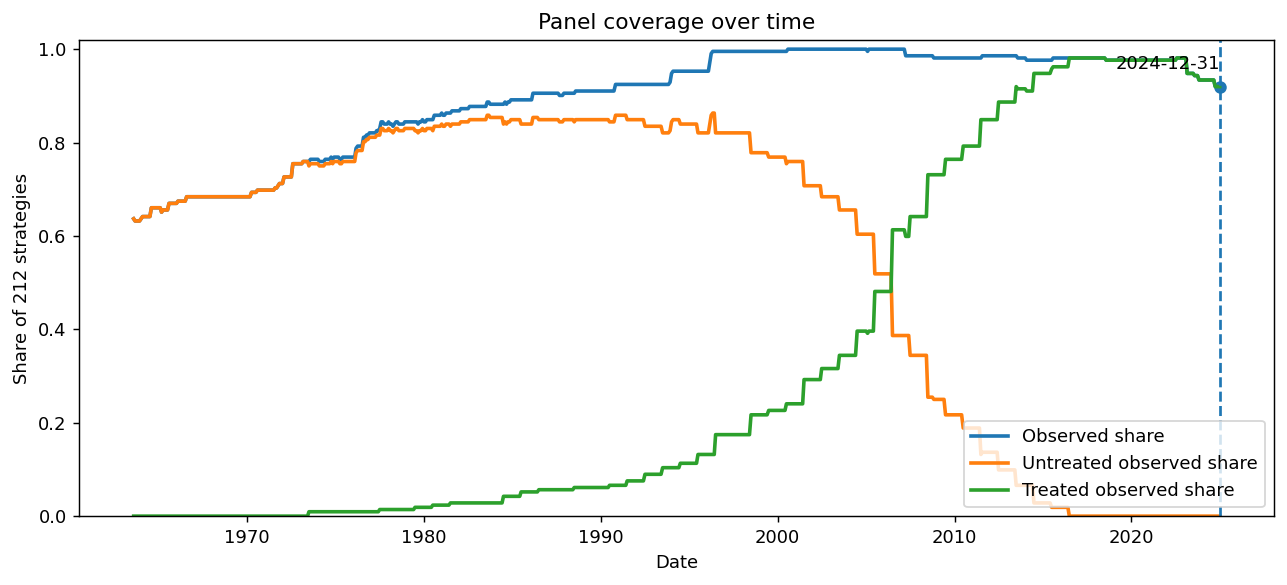

In [3]:

coverage = pd.Series(W.mean(axis=1), index=panel.index)
coverage_untreated = pd.Series(W0.mean(axis=1), index=panel.index)
coverage_treated = pd.Series((W * D).mean(axis=1), index=panel.index)

fig, ax = plt.subplots(figsize=(10, 4.6))
ax.plot(panel.index, coverage, label="Observed share", linewidth=2)
ax.plot(panel.index, coverage_untreated, label="Untreated observed share", linewidth=2)
ax.plot(panel.index, coverage_treated, label="Treated observed share", linewidth=2)
ax.axvline(END, linestyle="--", linewidth=1.5)
ax.scatter([END], [coverage.iloc[-1]], s=35)
ax.text(END, coverage.iloc[-1] + 0.03, "2024-12-31", ha="right", va="bottom")
ax.set_ylim(0, 1.02)
ax.set_title("Panel coverage over time")
ax.set_xlabel("Date")
ax.set_ylabel("Share of 212 strategies")
ax.legend(loc="lower right")
fig.tight_layout()
savefig("coverage_full_sample")
plt.show()


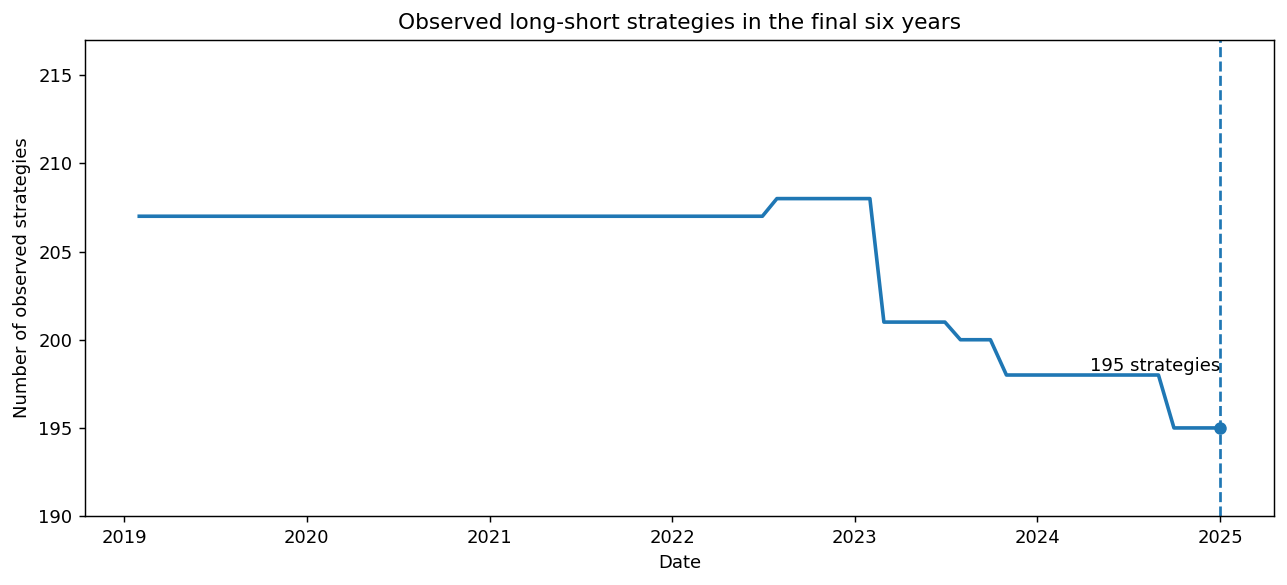

In [4]:

observed_count = pd.Series(W.sum(axis=1), index=panel.index)
zoom_count = observed_count.loc["2019-01-31":]

fig, ax = plt.subplots(figsize=(10, 4.6))
ax.plot(zoom_count.index, zoom_count, linewidth=2)
ax.axvline(END, linestyle="--", linewidth=1.5)
ax.scatter([END], [zoom_count.iloc[-1]], s=35)
ax.text(END, zoom_count.iloc[-1] + 3, f"{int(zoom_count.iloc[-1])} strategies", ha="right", va="bottom")
ax.set_ylim(max(0, zoom_count.min() - 5), N + 5)
ax.set_title("Observed long-short strategies in the final six years")
ax.set_xlabel("Date")
ax.set_ylabel("Number of observed strategies")
fig.tight_layout()
savefig("coverage_zoom_2019_2024")
plt.show()


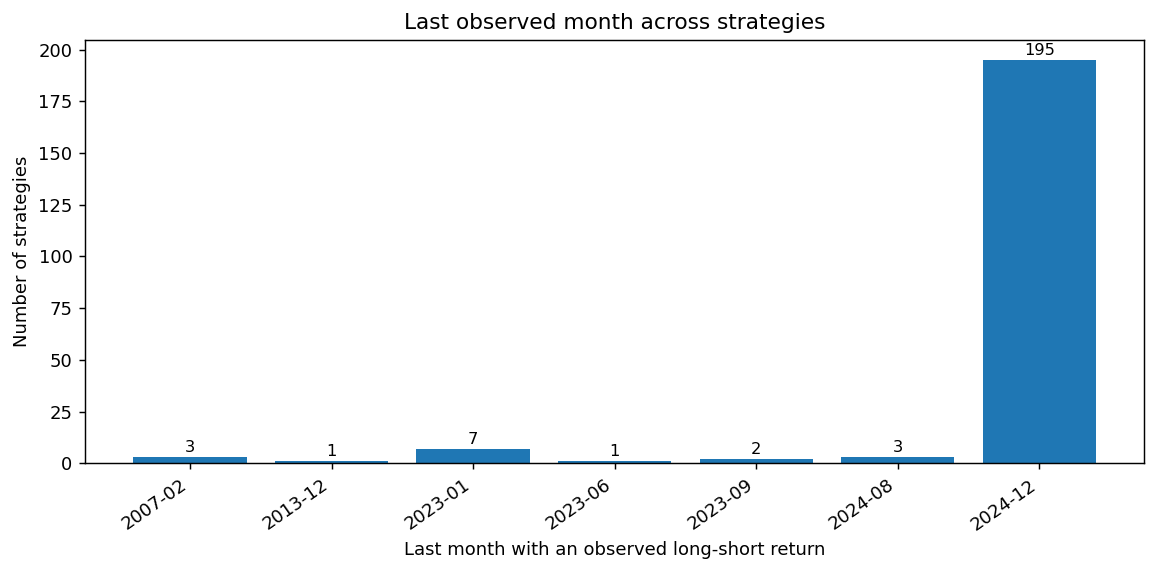

,last_observed_month,strategies
0,2007-02-28,3
1,2013-12-31,1
2,2023-01-31,7
3,2023-06-30,1
4,2023-09-29,2
5,2024-08-30,3
6,2024-12-31,195


In [5]:

last_obs_counts = last_obs.value_counts().sort_index()
last_obs_table = last_obs_counts.rename_axis("last_observed_month").reset_index(name="strategies")
last_obs_table.to_csv(OUTPUT / "last_observed_month_counts.csv", index=False)

fig, ax = plt.subplots(figsize=(9, 4.5))
xpos = np.arange(len(last_obs_counts))
ax.bar(xpos, last_obs_counts.values)
ax.set_xticks(xpos)
ax.set_xticklabels([d.strftime("%Y-%m") for d in last_obs_counts.index], rotation=35, ha="right")
ax.set_title("Last observed month across strategies")
ax.set_xlabel("Last month with an observed long-short return")
ax.set_ylabel("Number of strategies")
for i, v in enumerate(last_obs_counts.values):
    ax.text(i, v + 1, str(v), ha="center", va="bottom", fontsize=9)
fig.tight_layout()
savefig("last_observed_month_distribution")
plt.show()

display(last_obs_table)


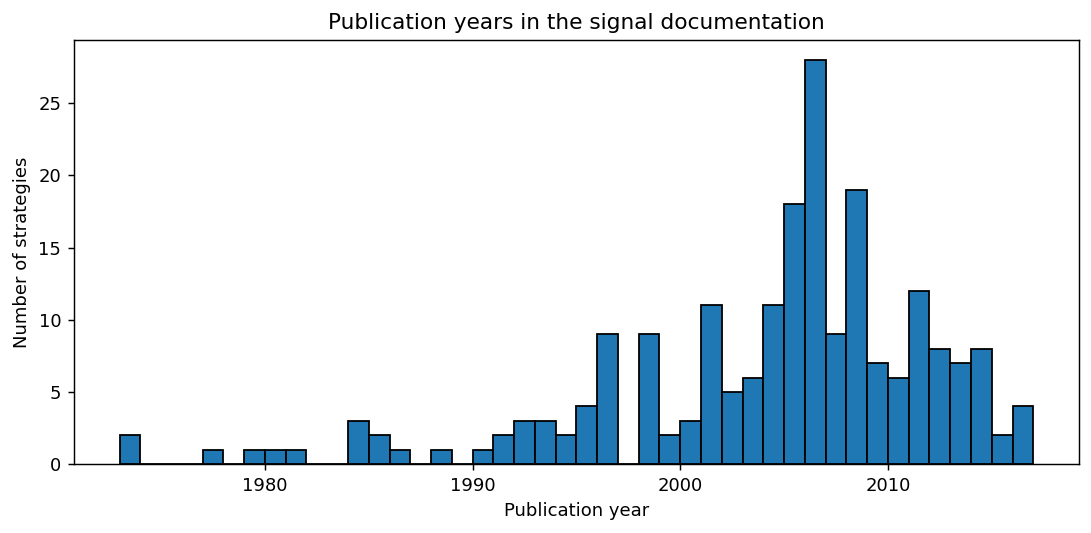

In [6]:

fig, ax = plt.subplots(figsize=(8.5, 4.2))
ax.hist(pub_year.values, bins=range(int(pub_year.min()), int(pub_year.max()) + 2), edgecolor="black")
ax.set_title("Publication years in the signal documentation")
ax.set_xlabel("Publication year")
ax.set_ylabel("Number of strategies")
fig.tight_layout()
savefig("publication_year_histogram")
plt.show()



## 2. Estimators

The baseline counterfactual is **rwiPCA**: two-way fixed effects are removed on the untreated panel, pairwise covariance is estimated using untreated overlaps, and factors are recovered with a ridge adjustment. For comparison, the notebook also builds:

- TWFE only,
- PCA without fixed effects,
- grouped time fixed effects plus rwiPCA,
- DR-rwiPCA,
- momentum-controlled rwiPCA.

The main cumulative-wealth figure excludes the DR and momentum-controlled variants, as requested. Those two variants appear separately just after the main figure.


In [7]:

def fit_twfe(Y_f, W0, max_iter=2000, tol=1e-8):
    T, N = Y_f.shape
    W0 = W0.astype(float)
    total_w = W0.sum()
    mu = (W0 * Y_f).sum() / total_w if total_w > 0 else 0.0
    alpha = np.zeros(N)
    xi = np.zeros(T)
    S_i = W0.sum(axis=0)
    S_t = W0.sum(axis=1)
    S_i_safe = np.where(S_i == 0, 1.0, S_i)
    S_t_safe = np.where(S_t == 0, 1.0, S_t)
    for _ in range(max_iter):
        mu_old = mu
        alpha_old = alpha.copy()
        xi_old = xi.copy()
        resid = Y_f - mu - xi[:, None]
        alpha = (W0 * resid).sum(axis=0) / S_i_safe
        alpha = alpha - alpha.mean()
        resid = Y_f - mu - alpha[None, :]
        xi = (W0 * resid).sum(axis=1) / S_t_safe
        xi = xi - xi.mean()
        resid = Y_f - alpha[None, :] - xi[:, None]
        mu = (W0 * resid).sum() / total_w if total_w > 0 else 0.0
        max_change = max(np.max(np.abs(alpha - alpha_old)), np.max(np.abs(xi - xi_old)), abs(mu - mu_old))
        if max_change < tol:
            break
    return mu, alpha, xi

def estimate_factors(dotY, W0, loadings, gamma):
    T, N = dotY.shape
    K = loadings.shape[1]
    F = np.zeros((T, K))
    for t in range(T):
        idx = np.where(W0[t, :] == 1)[0]
        if idx.size == 0:
            continue
        Lt = loadings[idx, :]
        yt = dotY[t, idx]
        A = Lt.T @ Lt + gamma * np.eye(K)
        b = Lt.T @ yt
        F[t, :] = np.linalg.solve(A, b)
    return F

def rwipca_predict(Y, W, D, K=4, gamma=0.0005, m_min=30):
    Y_f = np.nan_to_num(Y, nan=0.0)
    W0 = (W * (1 - D)).astype(int)
    mu, alpha, xi = fit_twfe(Y_f, W0, max_iter=4000, tol=1e-10)
    dotY = W0 * (Y_f - mu - alpha[None, :] - xi[:, None])
    M = W0.T @ W0
    S = dotY.T @ dotY
    Sigma = np.zeros((Y.shape[1], Y.shape[1]))
    mask = M >= m_min
    Sigma[mask] = S[mask] / M[mask]
    Sigma = (Sigma + Sigma.T) / 2
    diag = np.diag(M)
    Sigma[np.diag_indices(Y.shape[1])] = np.where(diag > 0, np.diag(S) / diag, 0.0)
    eigvals, eigvecs = np.linalg.eigh(Sigma)
    order = np.argsort(eigvals)[::-1]
    eigvals, eigvecs = eigvals[order], eigvecs[:, order]
    loadings = eigvecs[:, :K] * np.sqrt(np.maximum(eigvals[:K], 0))
    F = estimate_factors(dotY, W0, loadings, gamma)
    Y0_hat = mu + alpha[None, :] + xi[:, None] + F @ loadings.T
    info = {"mu": mu, "alpha": alpha, "xi": xi, "loadings": loadings, "F": F, "W0": W0, "dotY": dotY}
    return Y0_hat, info

def fit_groupfe(Y_f, W0, g_idx, b_idx, G, B, max_iter=2000, tol=1e-8):
    T, N = Y_f.shape
    W0 = W0.astype(float)
    total_w = W0.sum()
    mu = (W0 * Y_f).sum() / total_w if total_w > 0 else 0.0
    alpha = np.zeros(N)
    xi = np.zeros(T)
    eta = np.zeros((G, B))
    S_i = W0.sum(axis=0)
    S_t = W0.sum(axis=1)
    S_i_safe = np.where(S_i == 0, 1.0, S_i)
    S_t_safe = np.where(S_t == 0, 1.0, S_t)
    denom_eta = np.zeros((G, B))
    for t in range(T):
        b = b_idx[t]
        denom_eta[:, b] += np.bincount(g_idx, weights=W0[t, :], minlength=G)
    denom_eta_safe = np.where(denom_eta == 0, 1.0, denom_eta)
    for _ in range(max_iter):
        mu_old = mu
        alpha_old = alpha.copy()
        xi_old = xi.copy()
        eta_old = eta.copy()
        eta_ti = eta[g_idx[None, :], b_idx[:, None]]
        resid = Y_f - mu - xi[:, None] - eta_ti
        alpha = (W0 * resid).sum(axis=0) / S_i_safe
        alpha = alpha - alpha.mean()
        eta_ti = eta[g_idx[None, :], b_idx[:, None]]
        resid = Y_f - mu - alpha[None, :] - eta_ti
        xi = (W0 * resid).sum(axis=1) / S_t_safe
        xi = xi - xi.mean()
        resid = Y_f - mu - alpha[None, :] - xi[:, None]
        num_eta = np.zeros((G, B))
        for t in range(T):
            b = b_idx[t]
            num_eta[:, b] += np.bincount(g_idx, weights=W0[t, :] * resid[t, :], minlength=G)
        eta = num_eta / denom_eta_safe
        eta = eta - eta.mean()
        eta_ti = eta[g_idx[None, :], b_idx[:, None]]
        resid = Y_f - alpha[None, :] - xi[:, None] - eta_ti
        mu = (W0 * resid).sum() / total_w if total_w > 0 else 0.0
        max_change = max(
            np.max(np.abs(alpha - alpha_old)),
            np.max(np.abs(xi - xi_old)),
            np.max(np.abs(eta - eta_old)),
            abs(mu - mu_old),
        )
        if max_change < tol:
            break
    return mu, alpha, xi, eta

def fit_twfe_with_regressor(Y, W, X, max_iter=200, tol=1e-8):
    Y_f = np.nan_to_num(Y, nan=0.0)
    X_f = np.nan_to_num(X, nan=0.0)
    W = W.astype(float)
    beta = 0.0
    for _ in range(max_iter):
        beta_old = beta
        mu, alpha, xi = fit_twfe(Y_f - beta * X_f, W, max_iter=2000, tol=1e-10)
        resid = Y_f - mu - alpha[None, :] - xi[:, None]
        num = (W * X_f * resid).sum()
        den = (W * X_f * X_f).sum()
        beta = num / den if den > 0 else 0.0
        if abs(beta - beta_old) < tol:
            break
    return mu, alpha, xi, beta

def nw_long_run_var(x, L):
    x = np.asarray(x, dtype=float)
    n = len(x)
    x = x - x.mean()
    gamma0 = np.dot(x, x) / n
    omega = gamma0
    for k in range(1, L + 1):
        w = 1 - k / (L + 1)
        cov = np.dot(x[k:], x[:-k]) / n
        omega += 2 * w * cov
    return omega

def sectioning_omega(u, L):
    u = np.asarray(u, dtype=float)
    T = len(u)
    B = T // L
    if B < 2:
        return np.nan
    u_trunc = u[: B * L]
    u_blocks = u_trunc.reshape(B, L).mean(axis=1)
    u_bar = u_blocks.mean()
    return L / (B - 1) * np.sum((u_blocks - u_bar) ** 2)

def moving_block_bootstrap(u, L, B=800, rng=123):
    u = np.asarray(u, dtype=float)
    T = len(u)
    rng = np.random.default_rng(rng)
    atts = np.empty(B)
    for b in range(B):
        res = []
        while len(res) < T:
            start = rng.integers(0, T - L + 1)
            res.append(u[start : start + L])
        u_star = np.concatenate(res)[:T]
        atts[b] = u_star.mean()
    se = atts.std(ddof=1)
    ci = np.quantile(atts, [0.025, 0.975])
    return se, ci

def stationary_bootstrap(u, mean_block, B=800, rng=456):
    u = np.asarray(u, dtype=float)
    T = len(u)
    rng = np.random.default_rng(rng)
    p = 1 / mean_block
    atts = np.empty(B)
    for b in range(B):
        idxs = np.empty(T, dtype=int)
        idxs[0] = rng.integers(0, T)
        for t in range(1, T):
            if rng.random() < p:
                idxs[t] = rng.integers(0, T)
            else:
                idxs[t] = (idxs[t - 1] + 1) % T
        atts[b] = u[idxs].mean()
    se = atts.std(ddof=1)
    ci = np.quantile(atts, [0.025, 0.975])
    return se, ci

def ridge_factor_covariance(X, sigma2, gamma):
    K = X.shape[1]
    XtX = X.T @ X
    A = XtX + gamma * np.eye(K)
    A_inv = np.linalg.inv(A)
    return sigma2 * (A_inv @ XtX @ A_inv)

def event_time_mean_path(X, balanced_idx, pub_dates, date_to_idx, H=120):
    n = len(balanced_idx)
    ret_mat = np.zeros((H, n))
    for k, j in enumerate(balanced_idx):
        start = date_to_idx[pd.Timestamp(pub_dates[j])]
        ret_mat[:, k] = X[start : start + H, j]
    mean_ret = ret_mat.mean(axis=1)
    wealth = np.empty(H + 1)
    wealth[0] = 1.0
    for h in range(H):
        wealth[h + 1] = wealth[h] * (1 + mean_ret[h] / 100.0)
    return mean_ret, wealth


In [8]:

Y0_rw, info_rw = rwipca_predict(Y, W, D, K=K, gamma=GAMMA, m_min=M_MIN)
mu_hat, alpha_hat, xi_hat = info_rw["mu"], info_rw["alpha"], info_rw["xi"]
loadings = info_rw["loadings"]
F_hat = info_rw["F"]
dotY = info_rw["dotY"]
W0 = info_rw["W0"]

Y0_twfe = mu_hat + alpha_hat[None, :] + xi_hat[:, None]

mu_pca = (W0 * Y_f).sum() / W0.sum()
dotY_pca = W0 * (Y_f - mu_pca)
M = W0.T @ W0
S = dotY_pca.T @ dotY_pca
Sigma = np.zeros((N, N))
mask = M >= M_MIN
Sigma[mask] = S[mask] / M[mask]
Sigma = (Sigma + Sigma.T) / 2
diag = np.diag(M)
Sigma[np.diag_indices(N)] = np.where(diag > 0, np.diag(S) / diag, 0.0)
eigvals, eigvecs = np.linalg.eigh(Sigma)
order = np.argsort(eigvals)[::-1]
eigvals, eigvecs = eigvals[order], eigvecs[:, order]
loadings_p = eigvecs[:, :K] * np.sqrt(np.maximum(eigvals[:K], 0))
F_p = estimate_factors(dotY_pca, W0, loadings_p, GAMMA)
Y0_pca = mu_pca + F_p @ loadings_p.T

group_series = doc_sub["Cat.Data"]
groups_unique = sorted(group_series.unique())
G = len(groups_unique)
group_map = {g: i for i, g in enumerate(groups_unique)}
g_idx = group_series.map(group_map).values.astype(int)

years = date_pd.year.values
blocks_unique = sorted(np.unique(years))
B = len(blocks_unique)
block_map = {y: i for i, y in enumerate(blocks_unique)}
b_idx = np.array([block_map[y] for y in years], dtype=int)

mu_g, alpha_g, xi_g, eta_g = fit_groupfe(Y_f, W0, g_idx, b_idx, G, B, max_iter=800, tol=1e-8)
eta_ti = eta_g[g_idx[None, :], b_idx[:, None]]
dotY_g = W0 * (Y_f - mu_g - alpha_g[None, :] - xi_g[:, None] - eta_ti)

Sg = dotY_g.T @ dotY_g
Sig_g = np.zeros((N, N))
Sig_g[mask] = Sg[mask] / M[mask]
Sig_g = (Sig_g + Sig_g.T) / 2
Sig_g[np.diag_indices(N)] = np.where(diag > 0, np.diag(Sg) / diag, 0.0)
eigvals_g, eigvecs_g = np.linalg.eigh(Sig_g)
order = np.argsort(eigvals_g)[::-1]
eigvals_g, eigvecs_g = eigvals_g[order], eigvecs_g[:, order]
loadings_g = eigvecs_g[:, :K] * np.sqrt(np.maximum(eigvals_g[:K], 0))
F_g = estimate_factors(dotY_g, W0, loadings_g, GAMMA)
Y0_group = mu_g + alpha_g[None, :] + xi_g[:, None] + eta_ti + F_g @ loadings_g.T

mom = panel.rolling(window=12, min_periods=12).sum().shift(1).values
W_mom = ((W0 == 1) & (~np.isnan(mom))).astype(int)
mu_m, alpha_m, xi_m, beta_m = fit_twfe_with_regressor(Y, W_mom, mom, max_iter=120, tol=1e-9)
mom_f = np.nan_to_num(mom, nan=0.0)
m_hat = mu_m + alpha_m[None, :] + xi_m[:, None] + beta_m * mom_f
dotY_m = W0 * (Y_f - m_hat)

Sm = dotY_m.T @ dotY_m
Sig_m = np.zeros((N, N))
Sig_m[mask] = Sm[mask] / M[mask]
Sig_m = (Sig_m + Sig_m.T) / 2
Sig_m[np.diag_indices(N)] = np.where(diag > 0, np.diag(Sm) / diag, 0.0)
eigvals_m, eigvecs_m = np.linalg.eigh(Sig_m)
order = np.argsort(eigvals_m)[::-1]
eigvals_m, eigvecs_m = eigvals_m[order], eigvecs_m[:, order]
loadings_m = eigvecs_m[:, :K] * np.sqrt(np.maximum(eigvals_m[:K], 0))
F_m = estimate_factors(dotY_m, W0, loadings_m, GAMMA)
Y0_mom = m_hat + F_m @ loadings_m.T

p_t = W0.mean(axis=1)
dotY_dr = np.zeros_like(Y_f)
for t in range(T):
    if p_t[t] > 0:
        dotY_dr[t, :] = W0[t, :] * (Y_f[t, :] - Y0_twfe[t, :]) / p_t[t]

Sdr = dotY_dr.T @ dotY_dr
Sig_dr = np.zeros((N, N))
Sig_dr[mask] = Sdr[mask] / M[mask]
Sig_dr = (Sig_dr + Sig_dr.T) / 2
Sig_dr[np.diag_indices(N)] = np.where(diag > 0, np.diag(Sdr) / diag, 0.0)
eigvals_d, eigvecs_d = np.linalg.eigh(Sig_dr)
order = np.argsort(eigvals_d)[::-1]
eigvals_d, eigvecs_d = eigvals_d[order], eigvecs_d[:, order]
loadings_d = eigvecs_d[:, :K] * np.sqrt(np.maximum(eigvals_d[:K], 0))
F_d = estimate_factors(dotY_dr, W0, loadings_d, GAMMA)
Y0_dr = Y0_twfe + F_d @ loadings_d.T

_, wealth_obs = event_time_mean_path(Y_f, balanced_idx, pub_dates, date_to_idx, H=H)
_, wealth_rw = event_time_mean_path(Y0_rw, balanced_idx, pub_dates, date_to_idx, H=H)
_, wealth_group = event_time_mean_path(Y0_group, balanced_idx, pub_dates, date_to_idx, H=H)
_, wealth_twfe = event_time_mean_path(Y0_twfe, balanced_idx, pub_dates, date_to_idx, H=H)
_, wealth_pca = event_time_mean_path(Y0_pca, balanced_idx, pub_dates, date_to_idx, H=H)
_, wealth_dr = event_time_mean_path(Y0_dr, balanced_idx, pub_dates, date_to_idx, H=H)
_, wealth_mom = event_time_mean_path(Y0_mom, balanced_idx, pub_dates, date_to_idx, H=H)

wealth_summary = pd.DataFrame(
    {
        "Estimator": [
            "Observed",
            "rwiPCA",
            "Grouped FE rwiPCA",
            "TWFE",
            "PCA no FE",
            "DR-rwiPCA",
            "Momentum-controlled rwiPCA",
        ],
        "Terminal cumulative wealth at 120 months": [
            wealth_obs[-1],
            wealth_rw[-1],
            wealth_group[-1],
            wealth_twfe[-1],
            wealth_pca[-1],
            wealth_dr[-1],
            wealth_mom[-1],
        ],
    }
)
wealth_summary.to_csv(OUTPUT / "terminal_wealth_120m.csv", index=False)
display(wealth_summary)


,Estimator,Terminal cumulative wealth at 120 months
0,Observed,1.516
1,rwiPCA,1.759
2,Grouped FE rwiPCA,1.709
3,TWFE,1.811
4,PCA no FE,1.991
5,DR-rwiPCA,1.643
6,Momentum-controlled rwiPCA,1.702


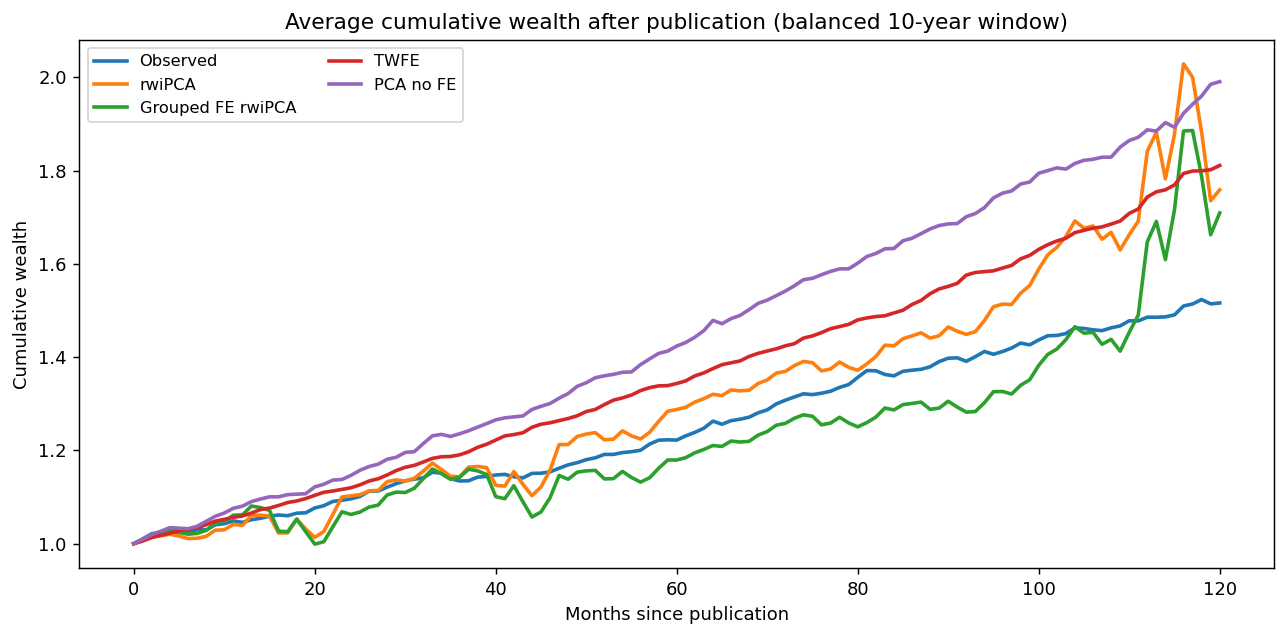

In [9]:

horizon_index = np.arange(H + 1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(horizon_index, wealth_obs, label="Observed", linewidth=2)
ax.plot(horizon_index, wealth_rw, label="rwiPCA", linewidth=2)
ax.plot(horizon_index, wealth_group, label="Grouped FE rwiPCA", linewidth=2)
ax.plot(horizon_index, wealth_twfe, label="TWFE", linewidth=2)
ax.plot(horizon_index, wealth_pca, label="PCA no FE", linewidth=2)
ax.set_title("Average cumulative wealth after publication (balanced 10-year window)")
ax.set_xlabel("Months since publication")
ax.set_ylabel("Cumulative wealth")
ax.legend(loc="upper left", ncol=2, fontsize=9)
fig.tight_layout()
savefig("figure2_main")
plt.show()



The momentum-controlled variant tracks baseline rwiPCA closely. The doubly robust variant is more conservative in levels, but it preserves the same broad post-publication pattern. That is consistent with what the estimators are doing: the momentum control absorbs a strong one-dimensional predictor, while the DR correction reweights observed untreated cells to guard against nonuniform observation probabilities.


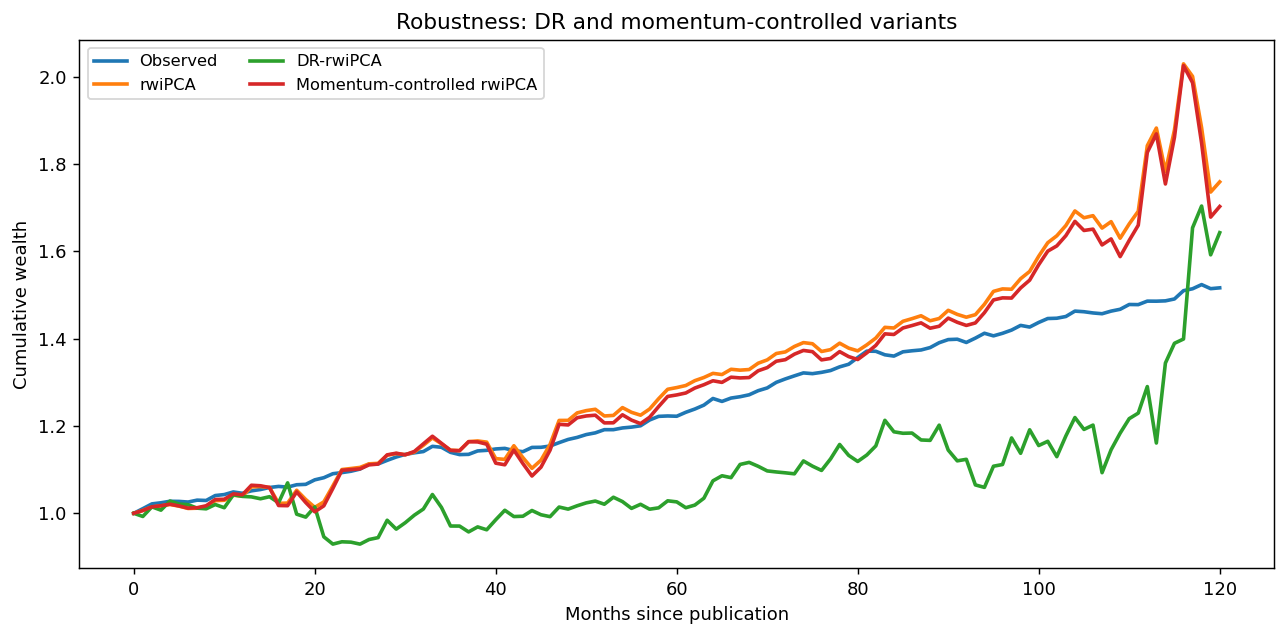

In [10]:

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(horizon_index, wealth_obs, label="Observed", linewidth=2)
ax.plot(horizon_index, wealth_rw, label="rwiPCA", linewidth=2)
ax.plot(horizon_index, wealth_dr, label="DR-rwiPCA", linewidth=2)
ax.plot(horizon_index, wealth_mom, label="Momentum-controlled rwiPCA", linewidth=2)
ax.set_title("Robustness: DR and momentum-controlled variants")
ax.set_xlabel("Months since publication")
ax.set_ylabel("Cumulative wealth")
ax.legend(loc="upper left", ncol=2, fontsize=9)
fig.tight_layout()
savefig("figure2_appendix_dr_momentum")
plt.show()



## 3. Strategy-level publication effects

For each strategy $i$, the notebook forms
$$
\widehat{\tau}_i=\frac{1}{H_i}\sum_{h=0}^{H_i-1}\Delta_{t_i+h,i},
\qquad
\Delta_{it}=Y_{it}-\widehat{Y}^{\,0}_{it},
$$
over the first ten post-publication years, with $H_i \le 120$ if the sample ends earlier. The next output summarizes the distribution of $\widehat{\tau}_i$, then lists **all** strategies partitioned into negative and nonnegative estimated effects.


,Measure,Value
0,Strategies with negative tau,124.000
1,Strategies with nonnegative tau,88.000
2,Mean tau,-0.164
3,Median tau,-0.116
4,10th percentile,-0.744
5,90th percentile,0.447


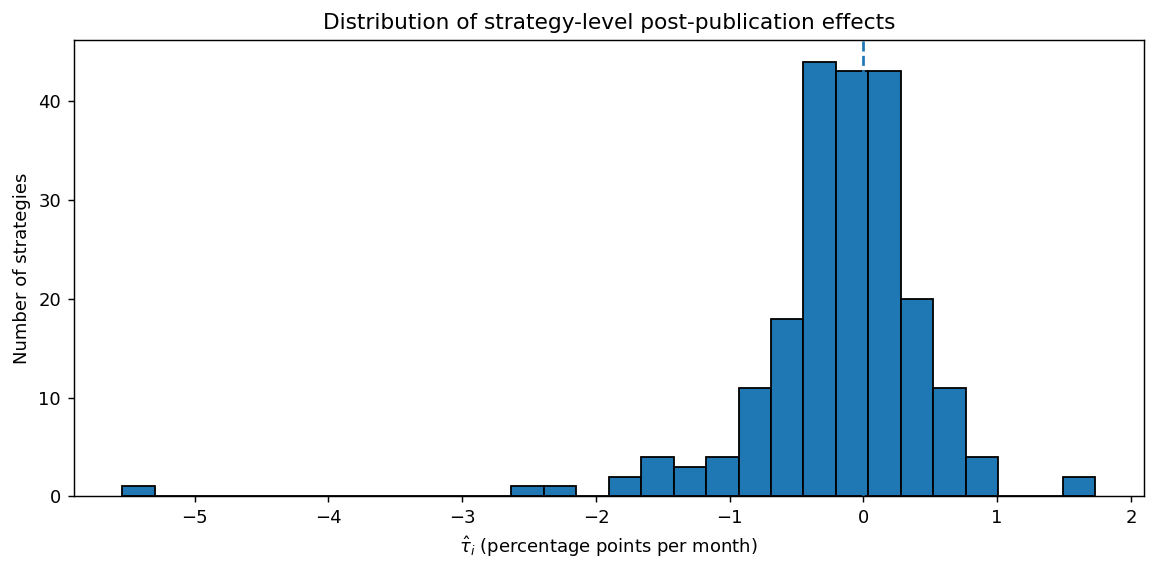

In [11]:

from math import erf, sqrt

def norm_cdf(x):
    return 0.5 * (1 + erf(x / sqrt(2)))

Delta_rw = Y_f - Y0_rw

strategy_stats = []
for j, sig in enumerate(signals):
    start = date_to_idx[pd.Timestamp(pub_dates[j])]
    end = min(start + H, T)
    series = Delta_rw[start:end, j]
    series = series[W[start:end, j] == 1]
    nobs = len(series)
    tau = series.mean() if nobs > 0 else np.nan
    L = min(12, nobs - 1) if nobs > 1 else 0
    omega = nw_long_run_var(series, L) if nobs > 1 else np.nan
    se = math.sqrt(omega / nobs) if nobs > 1 and omega >= 0 else np.nan
    tstat = tau / se if se and se > 0 else np.nan
    pval = 2 * (1 - norm_cdf(abs(tstat))) if np.isfinite(tstat) else np.nan
    strategy_stats.append((sig, int(pub_year.iloc[j]), tau, tstat, pval, nobs))

tau_df = pd.DataFrame(
    strategy_stats,
    columns=["strategy", "publication_year", "tau_hat", "t_stat", "p_value", "post_months"],
)
tau_df["sign"] = np.where(tau_df["tau_hat"] < 0, "negative", "nonnegative")
tau_df.to_csv(OUTPUT / "strategy_effects_full.csv", index=False)

tau_summary = pd.DataFrame(
    {
        "Measure": [
            "Strategies with negative tau",
            "Strategies with nonnegative tau",
            "Mean tau",
            "Median tau",
            "10th percentile",
            "90th percentile",
        ],
        "Value": [
            int((tau_df["tau_hat"] < 0).sum()),
            int((tau_df["tau_hat"] >= 0).sum()),
            tau_df["tau_hat"].mean(),
            tau_df["tau_hat"].median(),
            tau_df["tau_hat"].quantile(0.10),
            tau_df["tau_hat"].quantile(0.90),
        ],
    }
)

display(tau_summary)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(tau_df["tau_hat"].dropna(), bins=30, edgecolor="black")
ax.axvline(0, linestyle="--", linewidth=1.5)
ax.set_title("Distribution of strategy-level post-publication effects")
ax.set_xlabel(r"$\hat{\tau}_i$ (percentage points per month)")
ax.set_ylabel("Number of strategies")
fig.tight_layout()
savefig("tau_hat_histogram")
plt.show()


In [12]:

neg = tau_df.loc[tau_df["tau_hat"] < 0, ["strategy", "tau_hat", "post_months"]].sort_values("tau_hat").reset_index(drop=True)
pos = tau_df.loc[tau_df["tau_hat"] >= 0, ["strategy", "tau_hat", "post_months"]].sort_values("tau_hat", ascending=False).reset_index(drop=True)

rows = max(len(neg), len(pos))
partition_df = pd.DataFrame(
    {
        "Negative strategy": neg["strategy"].reindex(range(rows)),
        "tau_hat (neg)": neg["tau_hat"].reindex(range(rows)),
        "post months (neg)": neg["post_months"].reindex(range(rows)),
        "Positive strategy": pos["strategy"].reindex(range(rows)),
        "tau_hat (pos)": pos["tau_hat"].reindex(range(rows)),
        "post months (pos)": pos["post_months"].reindex(range(rows)),
    }
)
partition_df.to_csv(OUTPUT / "strategy_sign_partition.csv", index=False)
display(partition_df)


,Negative strategy,tau_hat (neg),post months (neg),Positive strategy,tau_hat (pos),post months (pos)
0,PatentsRD,-5.542,48,BetaFP,1.734,120.000
1,OptionVolume1,-2.549,120,IO_ShortInterest,1.712,120.000
2,MaxRet,-2.284,120,NetDebtPrice,0.954,120.000
3,RealizedVol,-1.878,120,RDcap,0.910,120.000
4,FEPS,-1.807,120,GP,0.870,120.000
5,IdioVol3F,-1.656,120,OrderBacklogChg,0.768,120.000
6,Frontier,-1.515,120,CompEquIss,0.721,120.000
7,DelDRC,-1.455,120,cfp,0.712,120.000
8,CashProd,-1.436,120,IndMom,0.676,120.000
9,MomOffSeason,-1.407,120,OPLeverage,0.657,120.000


## 4. Appendix E: calendar-time inference

Let
$$
u_t=\frac{T}{M}\sum_{i=1}^N \mathbf{1}\{D_{it}=1,\;W_{it}=1\}\,\Delta_{it},
\qquad
\widehat{\mathrm{ATT}}^{\mathrm{cal}}=\frac{1}{T}\sum_{t=1}^T u_t,
$$
where $M=\sum_{i,t}\mathbf{1}\{D_{it}=1,\;W_{it}=1\}$. The estimators below target the long-run variance of the score process $u_t$.

The default uncertainty report is based on a moving-block bootstrap. For comparison, the notebook also reports a sectioning estimator, a Newey–West estimator, and a conservative analytic benchmark in the spirit of plug-in variance decompositions used in large-dimensional factor-model asymptotics.


In [13]:

treated_mask = (D == 1) & (W == 1)
M_total = treated_mask.sum()

u = np.zeros(T)
for t in range(T):
    idx = np.where(treated_mask[t, :])[0]
    if idx.size > 0:
        u[t] = (T / M_total) * Delta_rw[t, idx].sum()

ATT_cal = float(u.mean())

L_nw = 12
omega_nw = nw_long_run_var(u, L_nw)
se_nw = math.sqrt(omega_nw / T)
ci_nw = (ATT_cal - 1.96 * se_nw, ATT_cal + 1.96 * se_nw)

L_blk = 6
omega_sec = sectioning_omega(u, L_blk)
se_sec = math.sqrt(omega_sec / T)
ci_sec = (ATT_cal - 1.96 * se_sec, ATT_cal + 1.96 * se_sec)

se_mbb, ci_mbb = moving_block_bootstrap(u, L=L_blk, B=800, rng=123)
se_sbb, ci_sbb = stationary_bootstrap(u, mean_block=L_blk, B=800, rng=456)

var_factor_t = np.zeros(T)
for t in range(T):
    treated_idx = np.where(treated_mask[t, :])[0]
    if treated_idx.size == 0:
        continue
    idx0 = np.where(W0[t, :] == 1)[0]
    if idx0.size == 0:
        continue
    X = loadings[idx0, :]
    resid = dotY[t, idx0] - X @ F_hat[t, :]
    sigma2 = float(np.mean(resid ** 2)) if resid.size > 0 else 0.0
    cov_f = ridge_factor_covariance(X, sigma2, GAMMA)
    vars_i = np.einsum("ik,kl,il->i", loadings[treated_idx, :], cov_f, loadings[treated_idx, :])
    scale = T / M_total
    var_factor_t[t] = (scale ** 2) * vars_i.sum()

omega_factor = float(var_factor_t.mean())
omega_px = omega_nw + omega_factor
se_px = math.sqrt(omega_px / T)
ci_px = (ATT_cal - 1.96 * se_px, ATT_cal + 1.96 * se_px)

inference_df = pd.DataFrame(
    {
        "Method": [
            "Newey-West HAC (lag 12)",
            "Sectioning (block 6)",
            "Moving-block bootstrap (block 6)",
            "Stationary bootstrap (mean block 6)",
            "Analytic plug-in (HAC + ridge factor term)",
        ],
        "Estimate": [ATT_cal] * 5,
        "Std. error": [se_nw, se_sec, se_mbb, se_sbb, se_px],
        "CI lower": [ci_nw[0], ci_sec[0], ci_mbb[0], ci_sbb[0], ci_px[0]],
        "CI upper": [ci_nw[1], ci_sec[1], ci_mbb[1], ci_sbb[1], ci_px[1]],
    }
)
inference_df.to_csv(OUTPUT / "appendix_e_inference.csv", index=False)
display(inference_df)


,Method,Estimate,Std. error,CI lower,CI upper
0,Newey-West HAC (lag 12),-0.191,0.075,-0.339,-0.043
1,Sectioning (block 6),-0.191,0.064,-0.317,-0.065
2,Moving-block bootstrap (block 6),-0.191,0.063,-0.320,-0.075
3,Stationary bootstrap (mean block 6),-0.191,0.071,-0.336,-0.054
4,Analytic plug-in (HAC + ridge factor term),-0.191,0.076,-0.340,-0.041


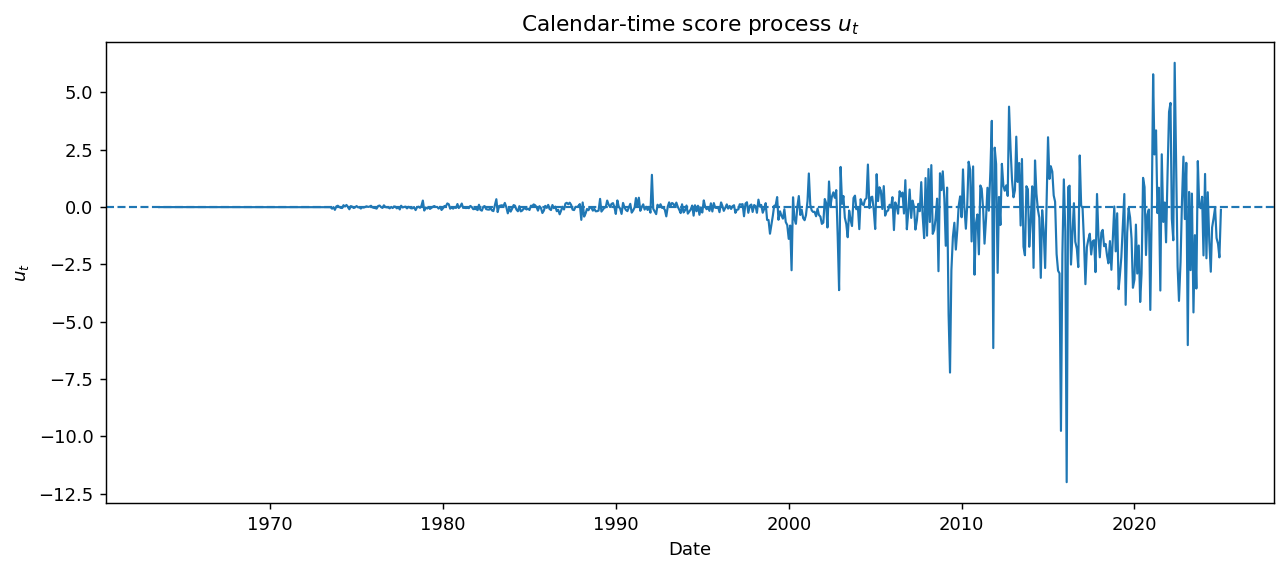

In [14]:

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(panel.index, u, linewidth=1.2)
ax.axhline(0, linestyle="--", linewidth=1.2)
ax.set_title(r"Calendar-time score process $u_t$")
ax.set_xlabel("Date")
ax.set_ylabel(r"$u_t$")
fig.tight_layout()
savefig("calendar_time_score_process")
plt.show()


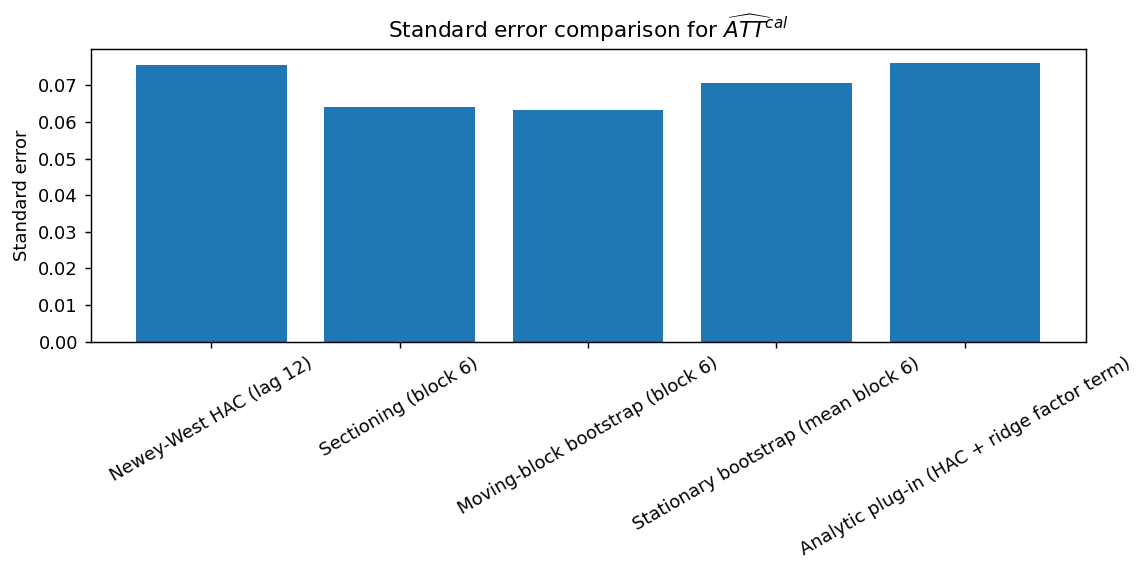

The analytic plug-in standard error is **0.076**, while the smallest resampling-based standard error is **0.063**.

In [15]:

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(inference_df["Method"], inference_df["Std. error"])
ax.set_title(r"Standard error comparison for $\widehat{ATT}^{cal}$")
ax.set_ylabel("Standard error")
ax.tick_params(axis="x", rotation=30)
fig.tight_layout()
savefig("appendix_e_se_comparison")
plt.show()

smallest_resampling = inference_df.loc[inference_df["Method"].isin(["Sectioning (block 6)", "Moving-block bootstrap (block 6)", "Stationary bootstrap (mean block 6)"]), "Std. error"].min()
display(Markdown(
    f"The analytic plug-in standard error is **{se_px:.3f}**, while the smallest resampling-based standard error is **{smallest_resampling:.3f}**."
))


## Files written to `outputs/notebook_outputs/`

The notebook saves the key plots and tables in plain formats:

- coverage diagnostics,
- the main and appendix cumulative-wealth figures,
- the full strategy sign partition,
- the Appendix E inference table and standard-error comparison plot.

This keeps the notebook readable on screen while making the underlying artifacts easy to reuse outside Jupyter.


In [16]:

output_index = pd.DataFrame({"file": sorted(p.name for p in OUTPUT.iterdir())})
display(output_index)


,file
0,appendix_e_inference.csv
1,appendix_e_se_comparison.pdf
2,appendix_e_se_comparison.png
3,calendar_time_score_process.pdf
4,calendar_time_score_process.png
5,coverage_full_sample.pdf
6,coverage_full_sample.png
7,coverage_zoom_2019_2024.pdf
8,coverage_zoom_2019_2024.png
9,figure2_appendix_dr_momentum.pdf
